# Topological MQA (TMQA) 2: `FakeMiami`
This is the second notebook for Topological MQA series. We will run the same process on `FakeMiami`, which is introduced as a part of [`FakeBackendV2`](https://quantum.cloud.ibm.com/docs/en/api/qiskit-ibm-runtime/fake-provider-fake-miami)

`FakeMiami` has 120 qubits with 10 x 12 arrangement. Here, FMQA will demonstrate TMQA with its square lattice.

In [ ]:
from qiskit_ibm_runtime.fake_provider.backends.miami import FakeMiami

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

import os
import random
import pathlib
import pickle

from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_device_benchmarking.bench_code.mrb import (
    MirrorQATopo,
    QuantumAwesomeness,
)

In [2]:
SEED = 123
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

shots = 1000
lengths = [2, 6, 14, 24, 30]
# lengths = [26, 40, 54, 68, 82]
num_samples = 100
num_lengths = len(lengths)

In [3]:
miami_hw = FakeMiami()
leqit = miami_hw.num_qubits # 120 qubits
faqe = leqit + 2

clifford_noise = NoiseModel.from_backend(
    miami_hw, 
    thermal_relaxation=False,
    readout_error=False # To match with our custom noise model from tmqa-simul.ipynb.
    )

miami_sim = AerSimulator.from_backend(miami_hw, noise_model=clifford_noise)
miami_sim.set_options(
    method='stabilizer',
    seed_simulator=SEED,
    # max_parallel_threads=0, # Use all available CPU cores
    max_parallel_experiments=0, # Run multiple circuits in parallel
)

In [4]:
exp = MirrorQATopo(
    range(leqit),
    lengths=lengths,
    sampling_algorithm="topo", # Use TopoSampler!
    mode="random", # Let 'full' and 'random' modes appear 50:50
    backend=miami_sim,
    # two_qubit_gate_density=0.5, # This doesn't matter with TopoSampler!
    num_samples=num_samples,
    initial_entangling_angle=np.pi / 2,
    ffw=1.3, # to make the appearance of two different modes 50:50
    seed=SEED,
)

exp.set_run_options(shots=shots)
exp.set_transpile_options(optimization_level=0)

In [26]:
miami_hw.configuration().basis_gates

['cz', 'id', 'rz', 'sx', 'x']

In [27]:
miami_hw.configuration().n_qubits

120

In [9]:
def dead_pairs(backend, threshold=0.5):
    t = backend.target
    cz = {tuple(sorted(q)): p.error
        for q, p in t["cz"].items()
        if q and p and p.error is not None}
    v = np.array(list(cz.values()))
    print(f"CZ error: median={np.median(v):.3f}  mean={v.mean():.3f}  max={v.max():.3f}")
    dead = sorted({e for e, err in cz.items() if err >= threshold})
    print(f"\n{len(dead)} dead CZ edges (error >= {threshold}):")
    for e in dead:
        print(f"   {e}  error={cz[e]:.3f}")
    return dead

DEAD = dead_pairs(FakeMiami())
print("\nqubits on dead edges:", sorted({q for e in DEAD for q in e}))

CZ error: median=0.003  mean=0.038  max=1.000

7 dead CZ edges (error >= 0.5):
   (21, 31)  error=1.000
   (66, 67)  error=1.000
   (68, 78)  error=1.000
   (74, 84)  error=1.000
   (91, 101)  error=1.000
   (93, 103)  error=1.000
   (111, 112)  error=1.000

qubits on dead edges: [21, 31, 66, 67, 68, 74, 78, 84, 91, 93, 101, 103, 111, 112]


### Import Helper functions

Below cells are for helper functions to:
1. Save the ongoing experiment as `.pkl` to the disk, so if the kernel crashes or the laptop goes to Sleep Mode, a researcher doesn't need to execute the entire experiment from the beginning again.
2. Analysis & Terminal printing: Definition of a *bot*, calculation of the `P(pairs)` and `P(topo)`.

In [10]:
# Part 1: Prepare .pkl
ckpt_dir = pathlib.Path("topo_ckpt")
ckpt_dir.mkdir(exist_ok=True)

In [11]:
# Part 2: Experiment side
# To deduct the mode for TopoSampler
def get_topo_mode(topo_full, fake_qubits):
    """f2f if the fake qubits paired together (or stayed unpaired); 
    f2g otherwise."""
    fake_pairs = [p for p in topo_full if any(q in fake_qubits for q in p)]
    if not fake_pairs:
        return "f2f"
    for p in fake_pairs:
        if all(q in fake_qubits for q in p):
            return "f2f"
    return "f2g"

In [12]:
# Calculates the MI from the result
def extract_mi(exp, rb_data, legit_qubits):
    legit_cmap = exp.backend.coupling_map.reduce(range(legit_qubits))
    qa = QuantumAwesomeness(legit_cmap)
    return qa.mutual_info(rb_data.data())

This is a bot.

In [41]:
def evaluate_bot(mi, exp, legit_qubits, num_qubits, acc=1.0):
    half = legit_qubits // 2
    fake_qubits = set(range(legit_qubits, num_qubits))

    bot_mode_ok = defaultdict(int)
    bot_pairs_ok = defaultdict(int)
    totals = defaultdict(int)

    for i, info in enumerate(mi):
        length = lengths[i % num_lengths]
        # sample = i // num_lengths

        topo_full = exp._topo_outcomes[i]
        topo_mode = get_topo_mode(topo_full, fake_qubits)

        G = nx.Graph()
        for (u, v), w in info.items():
            G.add_edge(u, v, weight=w)
        raw_guess = nx.max_weight_matching(G, maxcardinality=False, weight="weight")
        
        bot_pairs = sorted(tuple(sorted(p)) for p in raw_guess)
        
        bot_mode = "f2f" if len(bot_pairs) == half else "f2g"

        pairs_truth = sorted(tuple(sorted(p)) for p in exp._pairs[i])
        bot_mode_ok[length] += int(bot_mode == topo_mode)
        bot_pairs_ok[length] += int(
            len(set(bot_pairs) & set(pairs_truth)) >= acc * len(pairs_truth)
        )
        totals[length] += 1

    L = sorted(lengths)
    return {
        "lengths": L,
        "p_mode_topo": [bot_mode_ok[l] / totals[l] for l in L],
        "p_bot_pairs": [bot_pairs_ok[l] / totals[l] for l in L],
    }

## Run the experiment!

In [14]:
rb_data = exp.run()
rb_data.block_for_results()

ExperimentData(MirrorQATopo, dc3ee870-7553-4413-be53-9ce5e29b9c3e, job_ids=['488878cd-b576-4f19-96f0-dc554ccc3412'], metadata=<4 items>, figure_names=['MirrorQATopo_Q0_Q1_Q2_Q3_Q4_dc3ee870.svg'])

In [25]:
mi = extract_mi(exp, rb_data, leqit)
results = {}
results['miami'] = evaluate_bot(mi, exp, leqit, faqe, acc=0.90)

In [20]:
# Save cache
pickle.dump(results, open('topo_ckpt/miami_results_bot_0-90.pkl', 'wb'))

Before moving onto the bot analysis, we would review `FakeMiami`'s status so that even if there's any edges with 100% error rate, the entire snapshot wouldn't be considered as a wrong result.

In [19]:
files = sorted(pathlib.Path("topo_ckpt").glob("*.pkl"))
for i, f in enumerate(files):
    print(i, f.name)

blob = pickle.loads(files[0].read_bytes())  # change the index

0 miami_results_readout_False.pkl


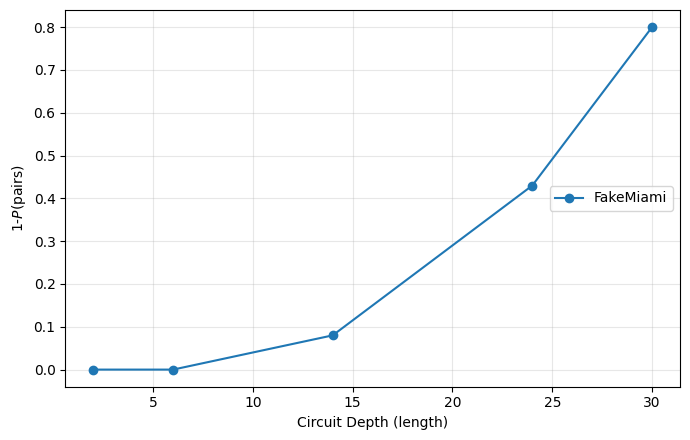

In [26]:
# A plot for P(pairs)
plt.figure(figsize=(7, 4.5))
y = [
    1 - p for p in results["miami"]["p_bot_pairs"]
]
plt.plot(
    results["miami"]["lengths"],
    y,
    marker="o",
    linestyle="-",
    label="FakeMiami",
)
plt.xlabel("Circuit Depth (length)")
plt.ylabel(r"1-$P(\mathrm{pairs})$")
plt.grid(True, alpha=0.3)
plt.legend(loc="center right", frameon=True)
plt.tight_layout()
plt.show()

In [ ]:
# A plot for P(topo) -> f2f/f2g from the matched-pair count (independent of `acc`)
plt.figure(figsize=(7, 4.5))
y = [
    1 - p for p in results["miami"]["p_mode_topo"]
]
plt.plot(
    results["miami"]["lengths"],
    y,
    marker="o",
    linestyle="-",
    label="FakeMiami",
)
plt.xlabel("Circuit Depth (length)")
plt.ylabel(r"1-$P(\mathrm{topo})$")
plt.grid(True, alpha=0.3)
plt.legend(loc="center right", frameon=True)
plt.tight_layout()
plt.show()